# Mass Balance — GRACE-aligned (3 mascon blocks)

Okavango Delta water budget with **P**, **ET**, **Q** and **GRACE ΔS** all
computed over the same three JPL mascon blocks (NE + SE + SW) that overlap the
delta polygon.  Dropping the NW block (1.6 % of the delta) eliminates a large
dry-Kalahari footprint while retaining 98.4 % of the delta polygon coverage.

$$Q_{\text{in}} + P - ET \approx \Delta S + Q_{\text{out}} + G$$

## 1 — Setup

In [1]:
from pathlib import Path
import hashlib
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import folium
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ee
from IPython.display import display
from shapely.geometry import box as shapely_box, Polygon, MultiPolygon
from shapely.ops import unary_union
from shapely.prepared import prep

from src.gee_utils import ee_init

# ── Paths ──
DELTA_SHP = Path("../data/regions/Delta_UCB_WGS84/Delta_UCB_WGS84.shp")
GRACE_NC  = Path("../data/grace_subsaharan_out/"
                  "GRCTellus.JPL.200204_202507.GLO.RL06.3M.MSCNv04CRI.nc")
MOHEMBO_MONTHLY = Path("../data/mohembo_1357100_Q_monthly_mean.csv")

assert DELTA_SHP.exists(), f"Missing: {DELTA_SHP.resolve()}"
assert GRACE_NC.exists(),  f"Missing: {GRACE_NC.resolve()}"

# ── Time window ──
START = "2002-04-01"   # GRACE begins April 2002
END = (pd.Timestamp.today().normalize()
       + pd.offsets.MonthBegin(1)).strftime("%Y-%m-%d")

# ── Output ──
GEOM_TAG = "grace_3block"
FIG_DIR  = Path("../figures/ET comparison") / GEOM_TAG
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Toggle: set False after EE calls have run once and CSVs are cached ──
RUN_EE = True

print(f"Window : {START} → {END}")
print(f"Figures: {FIG_DIR.resolve()}")

Window : 2002-04-01 → 2026-04-01
Figures: /Users/octaviacrompton/Projects/dswe-inman-lyons/figures/ET comparison/grace_3block


In [2]:
gdf = gpd.read_file(DELTA_SHP).to_crs(epsg=4326)
delta_union = gdf.unary_union
centroid = delta_union.centroid
print(f"Delta bounds: {delta_union.bounds}")

Delta bounds: (21.79128644270243, -20.185785441436625, 24.033221169007163, -18.26936168824883)


## 2 — Discover GRACE mascon blocks

In [3]:
ds_grace = xr.open_dataset(GRACE_NC)
da = ds_grace["lwe_thickness"]

lats_all = da["lat"].values
lons_all = da["lon"].values
dlat = float(np.median(np.abs(np.diff(lats_all))))
dlon = float(np.median(np.abs(np.diff(lons_all))))

# Generous window around the delta
pad_deg = 4.0
raw_minx, raw_miny, raw_maxx, raw_maxy = delta_union.bounds
da_sub = da.sel(
    lon=lons_all[(lons_all >= raw_minx - pad_deg) & (lons_all <= raw_maxx + pad_deg)],
    lat=lats_all[(lats_all >= raw_miny - pad_deg) & (lats_all <= raw_maxy + pad_deg)],
)

ts = (da_sub.stack(cell=("lat", "lon"))
      .transpose("time", "cell")
      .dropna("cell", how="all"))
cell_index = ts["cell"].to_index()
arr = ts.values

# Hash each 0.5° pixel's full time series → group into mascon blocks
groups = defaultdict(list)
for i in range(arr.shape[1]):
    v = np.round(arr[:, i].astype("float64"), 6)
    v = np.where(np.isnan(v), -9999.0, v)
    groups[hashlib.md5(v.tobytes()).hexdigest()].append(i)

delta_poly = (Polygon(delta_union.exterior.coords)
              if delta_union.geom_type == "Polygon" else delta_union)
P_prep = prep(delta_poly)

blocks = []
for k, idxs in enumerate(groups.values(), start=1):
    lc = np.array([cell_index[j][0] for j in idxs], dtype=float)
    lo = np.array([cell_index[j][1] for j in idxs], dtype=float)
    lat0, lat1 = float(lc.min() - dlat/2), float(lc.max() + dlat/2)
    lon0, lon1 = float(lo.min() - dlon/2), float(lo.max() + dlon/2)
    bpoly = shapely_box(lon0, lat0, lon1, lat1)

    blat_c = (lat0 + lat1) / 2
    blon_c = (lon0 + lon1) / 2
    ns = "N" if blat_c > centroid.y else "S"
    ew = "W" if blon_c < centroid.x else "E"

    blocks.append(dict(
        block_id=f"B{k:03d}", quadrant=f"{ns}{ew}",
        lat0=lat0, lat1=lat1, lon0=lon0, lon1=lon1,
        n_pixels=len(idxs),
        intersects_delta=P_prep.intersects(bpoly),
    ))

ds_grace.close()

delta_blocks = [b for b in blocks if b["intersects_delta"]]
for b in sorted(delta_blocks, key=lambda x: (-x["lat1"], x["lon0"])):
    bpoly = shapely_box(b["lon0"], b["lat0"], b["lon1"], b["lat1"])
    frac = delta_poly.intersection(bpoly).area / delta_poly.area
    print(f"  {b['block_id']}  ({b['quadrant']})  "
          f"lon {b['lon0']:6.2f}–{b['lon1']:6.2f}  "
          f"lat {b['lat0']:7.2f}–{b['lat1']:6.2f}  "
          f"frac_delta={frac:.1%}")

  B010  (NW)  lon  19.00– 22.00  lat  -19.50–-16.50  frac_delta=1.6%
  B011  (NE)  lon  22.00– 25.50  lat  -19.50–-16.50  frac_delta=60.7%
  B006  (SW)  lon  19.50– 22.50  lat  -22.50–-19.50  frac_delta=4.7%
  B007  (SE)  lon  22.50– 25.50  lat  -22.50–-19.50  frac_delta=33.0%


In [4]:
# Drop the NW block (< 2 % of delta)
USE_BLOCKS = [b for b in delta_blocks if b["quadrant"] != "NW"]
print("Selected blocks:", [b["block_id"] + " " + b["quadrant"] for b in USE_BLOCKS])

block_polys = [shapely_box(b["lon0"], b["lat0"], b["lon1"], b["lat1"])
               for b in USE_BLOCKS]
block_union = unary_union(block_polys)

block_union_area_deg2 = block_union.area
frac_covered = sum(
    delta_poly.intersection(p).area for p in block_polys
) / delta_poly.area
print(f"3-block union area   : ~{block_union_area_deg2:.1f} deg²")
print(f"Delta polygon covered: {frac_covered:.1%}")

Selected blocks: ['B006 SW', 'B007 SE', 'B011 NE']
3-block union area   : ~28.5 deg²
Delta polygon covered: 98.4%


In [5]:
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=7, tiles=None)

folium.TileLayer("CartoDB positron", name="Carto Positron").add_to(m)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/"
          "World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri", name="Esri Imagery", overlay=False, control=True,
).add_to(m)

# Delta polygon
folium.GeoJson(
    gdf.__geo_interface__, name="Delta polygon",
    style_function=lambda f: {"color": "#8c2d04", "weight": 3, "fillOpacity": 0.15},
).add_to(m)

# All discovered blocks (grey for non-selected)
grid_fg = folium.FeatureGroup(name="Mascon blocks (all)", show=True)
for b in blocks:
    selected = any(b["block_id"] == u["block_id"] for u in USE_BLOCKS)
    folium.Rectangle(
        bounds=[[b["lat0"], b["lon0"]], [b["lat1"], b["lon1"]]],
        color="#1b9e77" if selected else "#bbbbbb",
        weight=2 if selected else 1,
        fill=selected, fill_opacity=0.12 if selected else 0.0,
        tooltip=f"{b['block_id']} ({b['quadrant']})  {b['n_pixels']} px",
    ).add_to(grid_fg)
grid_fg.add_to(m)

# 3-block union outline
ub = block_union.bounds
folium.Rectangle(
    bounds=[[ub[1], ub[0]], [ub[3], ub[2]]],
    color="#2ca02c", weight=3, fill=False, dash_array="6",
    tooltip="3-block union",
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

## 3 — Earth Engine geometry + area

In [6]:
ee_init()

# Build an EE MultiPolygon from the Shapely block geometries
coords_list = []
for bp in block_polys:
    coords_list.append([list(c) for c in bp.exterior.coords])

block_geom = ee.Geometry.MultiPolygon(coords_list, proj="EPSG:4326", geodesic=True)
block_area_m2 = float(block_geom.area(maxError=1).getInfo())
print(f"3-block union area (EE): {block_area_m2 / 1e6:.0f} km²")

3-block union area (EE): 331266 km²


## 4 — Monthly ET over 3-block union

In [7]:
# ── Reusable helper functions (same as ET comparison notebook) ──

def monthly_sequence(start_date, end_date):
    s, e = ee.Date(start_date), ee.Date(end_date)
    return ee.List.sequence(0, e.difference(s, "month").toInt().subtract(1))

def make_monthly_et_ic(ic, to_mm_fn, start_date, end_date):
    start = ee.Date(start_date)
    def month_img(m):
        m = ee.Number(m)
        m0 = start.advance(m, "month")
        m1 = m0.advance(1, "month")
        sub = ic.filterDate(m0, m1).map(to_mm_fn)
        mm = ee.Image(ee.Algorithms.If(sub.size().gt(0), sub.sum(),
                                        ee.Image.constant(0)))
        return (mm.rename("et_mm")
                .set({"system:time_start": m0.millis(),
                      "system:index": m0.format("YYYYMM"),
                      "ym": m0.format("YYYY-MM")}))
    months = ee.List(ee.Algorithms.If(
        ee.Date(end_date).difference(start, "month").toInt().gt(0),
        monthly_sequence(start_date, end_date), ee.List([])))
    return ee.ImageCollection.fromImages(months.map(month_img))

def monthly_totals_m3_chunked(monthly_ic, region, scale_m,
                               chunk_months=24, tile_scale=8):
    n = int(monthly_ic.size().getInfo())
    if n == 0:
        return {}
    imgs = monthly_ic.toList(n)
    out = {}
    for i in range(0, n, chunk_months):
        sub = ee.ImageCollection.fromImages(imgs.slice(i, min(i + chunk_months, n)))
        def to_m3(img):
            img = ee.Image(img)
            idx = ee.String(img.get("system:index"))
            return (img.select("et_mm").unmask(0)
                    .divide(1000).multiply(ee.Image.pixelArea())
                    .rename("et_m3").set("system:index", idx))
        bands_img = sub.map(to_m3).toBands()
        d = bands_img.reduceRegion(
            reducer=ee.Reducer.sum(), geometry=region,
            scale=scale_m, maxPixels=1e13, tileScale=tile_scale).getInfo()
        out.update(d)
    return out

def et_totals_to_df(totals, dataset_name, area_m2):
    rows = []
    for k, v in totals.items():
        yyyymm = k.split("_")[0]
        date = pd.to_datetime(yyyymm + "01", format="%Y%m%d")
        m3 = float(v) if v is not None else 0.0
        rows.append({"dataset": dataset_name, "date": date,
                      "et_km3_total": m3 / 1e9,
                      "et_mm_mean": (m3 / area_m2) * 1000.0})
    return pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

print("ET helpers defined.")

ET helpers defined.


In [8]:
# ── Converter functions (native timestep → mm) ──
def mod16_mm(img):
    return img.select("ET").multiply(0.1)

def terraclimate_mm(img):
    return img.select("aet").multiply(0.1)

def fldas_mm(img):
    d0 = ee.Date(img.get("system:time_start"))
    secs = d0.advance(1, "month").difference(d0, "second")
    return img.select("Evap_tavg").multiply(secs)

def era5_land_mm(img):
    return img.select("total_evaporation_sum").multiply(-1000)

def pml_mm(img):
    return img.select("ET").multiply(0.01).multiply(8)

def wapor_mm(img):
    d0 = ee.Date(img.get("system:time_start"))
    d1_cand = d0.advance(10, "day")
    m_end = ee.Date.fromYMD(d0.get("year"), d0.get("month"), 1).advance(1, "month")
    d1 = ee.Date(ee.Algorithms.If(d1_cand.millis().lte(m_end.millis()), d1_cand, m_end))
    return img.select("L1-AETI-D").multiply(0.1).multiply(d1.difference(d0, "day"))

DATASETS = [
    dict(name="MOD16A2GF_v61",    id="MODIS/061/MOD16A2GF",  to_mm=mod16_mm,  scale=500,   start="2000-01-01"),
    dict(name="PML_v2_landET",     id="projects/pml_evapotranspiration/PML/OUTPUT/PML_V22a",
         to_mm=pml_mm, scale=500, start="2000-01-01"),
    dict(name="TerraClimate_aet",  id="IDAHO_EPSCOR/TERRACLIMATE",  to_mm=terraclimate_mm,  scale=4638,  start="1958-01-01"),
    dict(name="FLDAS_Evap",        id="NASA/FLDAS/NOAH01/C/GL/M/V001",  to_mm=fldas_mm,  scale=11132, start="1982-01-01"),
    dict(name="ERA5Land_totalET",  id="ECMWF/ERA5_LAND/MONTHLY_AGGR",   to_mm=era5_land_mm, scale=11132, start="1950-02-01"),
    dict(name="USGS_SSEBop",
         id="projects/earthengine-legacy/assets/projects/usgs-ssebop/modis_et_v5_monthly",
         to_mm=lambda img: img.select("et"), scale=1000, start="2003-01-01"),
    dict(name="WaPORv3_AETI",      id="FAO/WAPOR/3/L1_AETI_D",  to_mm=wapor_mm,  scale=248,  start="2018-01-01"),
]

ET_CSV = FIG_DIR / "et_monthly.csv"

if RUN_EE:
    dfs_et = []
    for ds in DATASETS:
        ds_start = max(pd.to_datetime(START), pd.to_datetime(ds["start"])).strftime("%Y-%m-%d")
        if pd.to_datetime(ds_start) >= pd.to_datetime(END):
            continue
        ic = (ee.ImageCollection(ds["id"])
              .filterBounds(block_geom).filterDate(ds_start, END))
        mic = make_monthly_et_ic(ic, ds["to_mm"], ds_start, END)
        n = int(mic.size().getInfo())
        print(f"{ds['name']}: {n} months  ({ds_start} → {END})")
        totals = monthly_totals_m3_chunked(mic, block_geom, scale_m=ds["scale"])
        dfs_et.append(et_totals_to_df(totals, ds["name"], block_area_m2))

    df_et_all = pd.concat(dfs_et, ignore_index=True).sort_values(["dataset", "date"])
    df_et_all.to_csv(ET_CSV, index=False)
    print(f"Saved: {ET_CSV}  ({len(df_et_all)} rows)")
else:
    df_et_all = pd.read_csv(ET_CSV, parse_dates=["date"])
    print(f"Loaded cached: {ET_CSV}  ({len(df_et_all)} rows)")

MOD16A2GF_v61: 288 months  (2002-04-01 → 2026-04-01)
PML_v2_landET: 288 months  (2002-04-01 → 2026-04-01)
TerraClimate_aet: 288 months  (2002-04-01 → 2026-04-01)
FLDAS_Evap: 288 months  (2002-04-01 → 2026-04-01)
ERA5Land_totalET: 288 months  (2002-04-01 → 2026-04-01)
USGS_SSEBop: 278 months  (2003-01-01 → 2026-04-01)
WaPORv3_AETI: 98 months  (2018-01-01 → 2026-04-01)
Saved: ../figures/ET comparison/grace_3block/et_monthly.csv  (1816 rows)


In [9]:
# ── GLEAM v4.2a monthly ET (from local netCDFs) ──
GLEAM_DIR = Path("../data/gleam")
GLEAM_FILES = sorted(GLEAM_DIR.glob("E_*_GLEAM_v4.2a_MO.nc"))

if GLEAM_FILES:
    # Bounding box of the 3-block union for spatial clip
    blon0, blat0, blon1, blat1 = block_union.bounds

    dsets = []
    for f in GLEAM_FILES:
        ds = xr.open_dataset(f)
        # GLEAM v4.2a has lat descending (90 → -90), so slice high → low
        dsets.append(ds.sel(lon=slice(blon0 - 0.5, blon1 + 0.5),
                            lat=slice(blat1 + 0.5, blat0 - 0.5)))

    da_gleam = xr.concat(dsets, dim="time").sortby("time")
    for d in dsets:
        d.close()

    et_da = da_gleam["E"]  # actual ET in mm/month

    # Build pixel-area weights (cos-lat on regular 0.1° grid)
    lats = et_da["lat"].values
    lons = et_da["lon"].values
    dlat_g = abs(float(np.median(np.diff(lats))))
    dlon_g = abs(float(np.median(np.diff(lons))))

    R = 6.371e6  # Earth radius in metres
    pixel_area = (R**2 * np.deg2rad(dlon_g)
                  * np.abs(np.sin(np.deg2rad(lats + dlat_g / 2))
                           - np.sin(np.deg2rad(lats - dlat_g / 2))))
    area_2d = np.broadcast_to(pixel_area[:, None], (len(lats), len(lons)))

    # Mask: only pixels whose centre falls inside the 3-block union
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    from shapely.vectorized import contains
    mask = contains(block_union, lon_grid, lat_grid)

    total_area = float(area_2d[mask].sum())

    rows = []
    for t in range(et_da.shape[0]):
        vals = et_da.values[t]  # mm/month per pixel
        m3 = float(np.nansum(np.where(mask, vals, 0.0) * area_2d / 1000.0))
        mm_mean = (m3 / total_area) * 1000.0 if total_area > 0 else 0.0
        ts_val = pd.Timestamp(et_da["time"].values[t])
        rows.append({"dataset": "GLEAM_v42a", "date": ts_val,
                      "et_km3_total": m3 / 1e9, "et_mm_mean": mm_mean})

    df_gleam = pd.DataFrame(rows)
    df_gleam = df_gleam[(df_gleam["date"] >= START) & (df_gleam["date"] < END)]
    df_gleam = df_gleam.sort_values("date").reset_index(drop=True)

    da_gleam.close()

    # Append to df_et_all
    df_et_all = pd.concat([df_et_all, df_gleam], ignore_index=True).sort_values(
        ["dataset", "date"]).reset_index(drop=True)
    df_et_all.to_csv(ET_CSV, index=False)
    print(f"GLEAM_v42a: {len(df_gleam)} months added  "
          f"(mean ET = {df_gleam['et_mm_mean'].mean():.1f} mm/month)")
    print(f"Updated: {ET_CSV}  ({len(df_et_all)} total rows)")
else:
    print("No GLEAM files found in data/gleam/ — run:  python scripts/download_gleam.py")

GLEAM_v42a: 273 months added  (mean ET = 45.4 mm/month)
Updated: ../figures/ET comparison/grace_3block/et_monthly.csv  (2089 total rows)


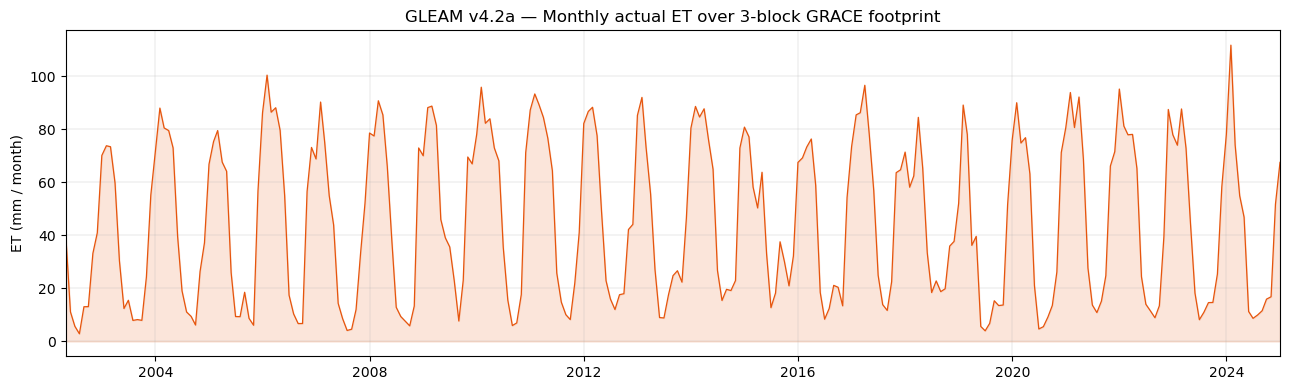

Period: 2002-04-30 → 2024-12-31
Mean: 45.4 mm/month  |  Min: 2.9  |  Max: 111.8


In [10]:
# ── Plot: GLEAM v4.2a monthly ET ──
gleam_sub = df_et_all[df_et_all["dataset"] == "GLEAM_v42a"].copy()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(gleam_sub["date"], gleam_sub["et_mm_mean"], lw=0.9, color="#e6550d")
ax.fill_between(gleam_sub["date"], 0, gleam_sub["et_mm_mean"],
                alpha=0.15, color="#e6550d")
ax.set_title("GLEAM v4.2a — Monthly actual ET over 3-block GRACE footprint")
ax.set_ylabel("ET (mm / month)")
ax.set_xlim(gleam_sub["date"].min(), gleam_sub["date"].max())
ax.grid(True, lw=0.2)
plt.tight_layout()
plt.show()

print(f"Period: {gleam_sub['date'].min().date()} → {gleam_sub['date'].max().date()}")
print(f"Mean: {gleam_sub['et_mm_mean'].mean():.1f} mm/month  |  "
      f"Min: {gleam_sub['et_mm_mean'].min():.1f}  |  Max: {gleam_sub['et_mm_mean'].max():.1f}")

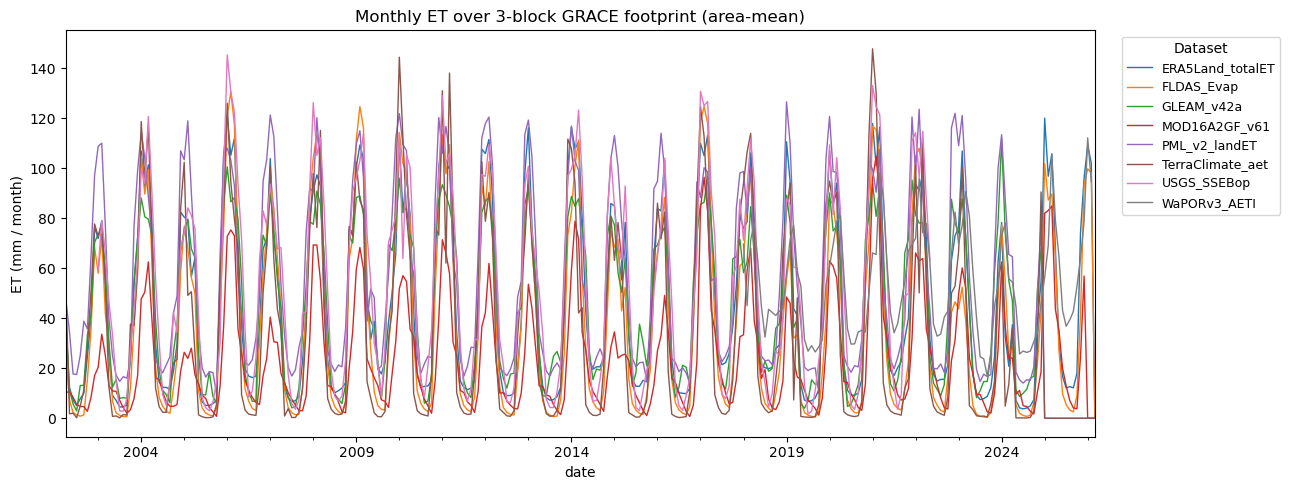

In [19]:
# ── SSEBop zero-padding cleanup ──
ssebop_mask = df_et_all["dataset"].str.contains("SSEBop", case=False)
tiny = 1e-6
if ssebop_mask.any():
    zeros = (df_et_all.loc[ssebop_mask, "et_km3_total"].le(tiny)
             & df_et_all.loc[ssebop_mask, "et_km3_total"].notna())
    if zeros.sum() > 0:
        last_real = df_et_all.loc[ssebop_mask & (df_et_all["et_km3_total"] > tiny), "date"].max()
        df_et_all.loc[ssebop_mask & df_et_all["et_km3_total"].le(tiny), "et_km3_total"] = np.nan
        df_et_all.loc[ssebop_mask & df_et_all["et_mm_mean"].le(tiny),   "et_mm_mean"]   = np.nan
        if pd.notna(last_real):
            df_et_all.loc[ssebop_mask & (df_et_all["date"] > last_real),
                          ["et_km3_total", "et_mm_mean"]] = np.nan
        print(f"SSEBop: blanked {zeros.sum()} zero-padded rows (last real: {last_real})")

# ── Plot: all ET products (mm/month) ──
wide_et_mm = (df_et_all.pivot_table(index="date", columns="dataset",
                                     values="et_mm_mean", aggfunc="mean")
              .sort_index())

fig, ax = plt.subplots(figsize=(13, 5))
wide_et_mm.plot(ax=ax, linewidth=1)
ax.set_title("Monthly ET over 3-block GRACE footprint (area-mean)")
ax.set_ylabel("ET (mm / month)")
ax.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## ET Diagnostic: Delta Polygon vs 3-Block GRACE Domain

Delta polygon area (EE): 23387 km²
  MOD16A2GF_v61: 288 months
  PML_v2_landET: 288 months
  TerraClimate_aet: 288 months
  FLDAS_Evap: 288 months
  ERA5Land_totalET: 288 months
  USGS_SSEBop: 278 months
  WaPORv3_AETI: 98 months
Saved: ../figures/ET comparison/grace_3block/et_monthly_delta_poly.csv  (1816 rows)
GLEAM delta: 273 months


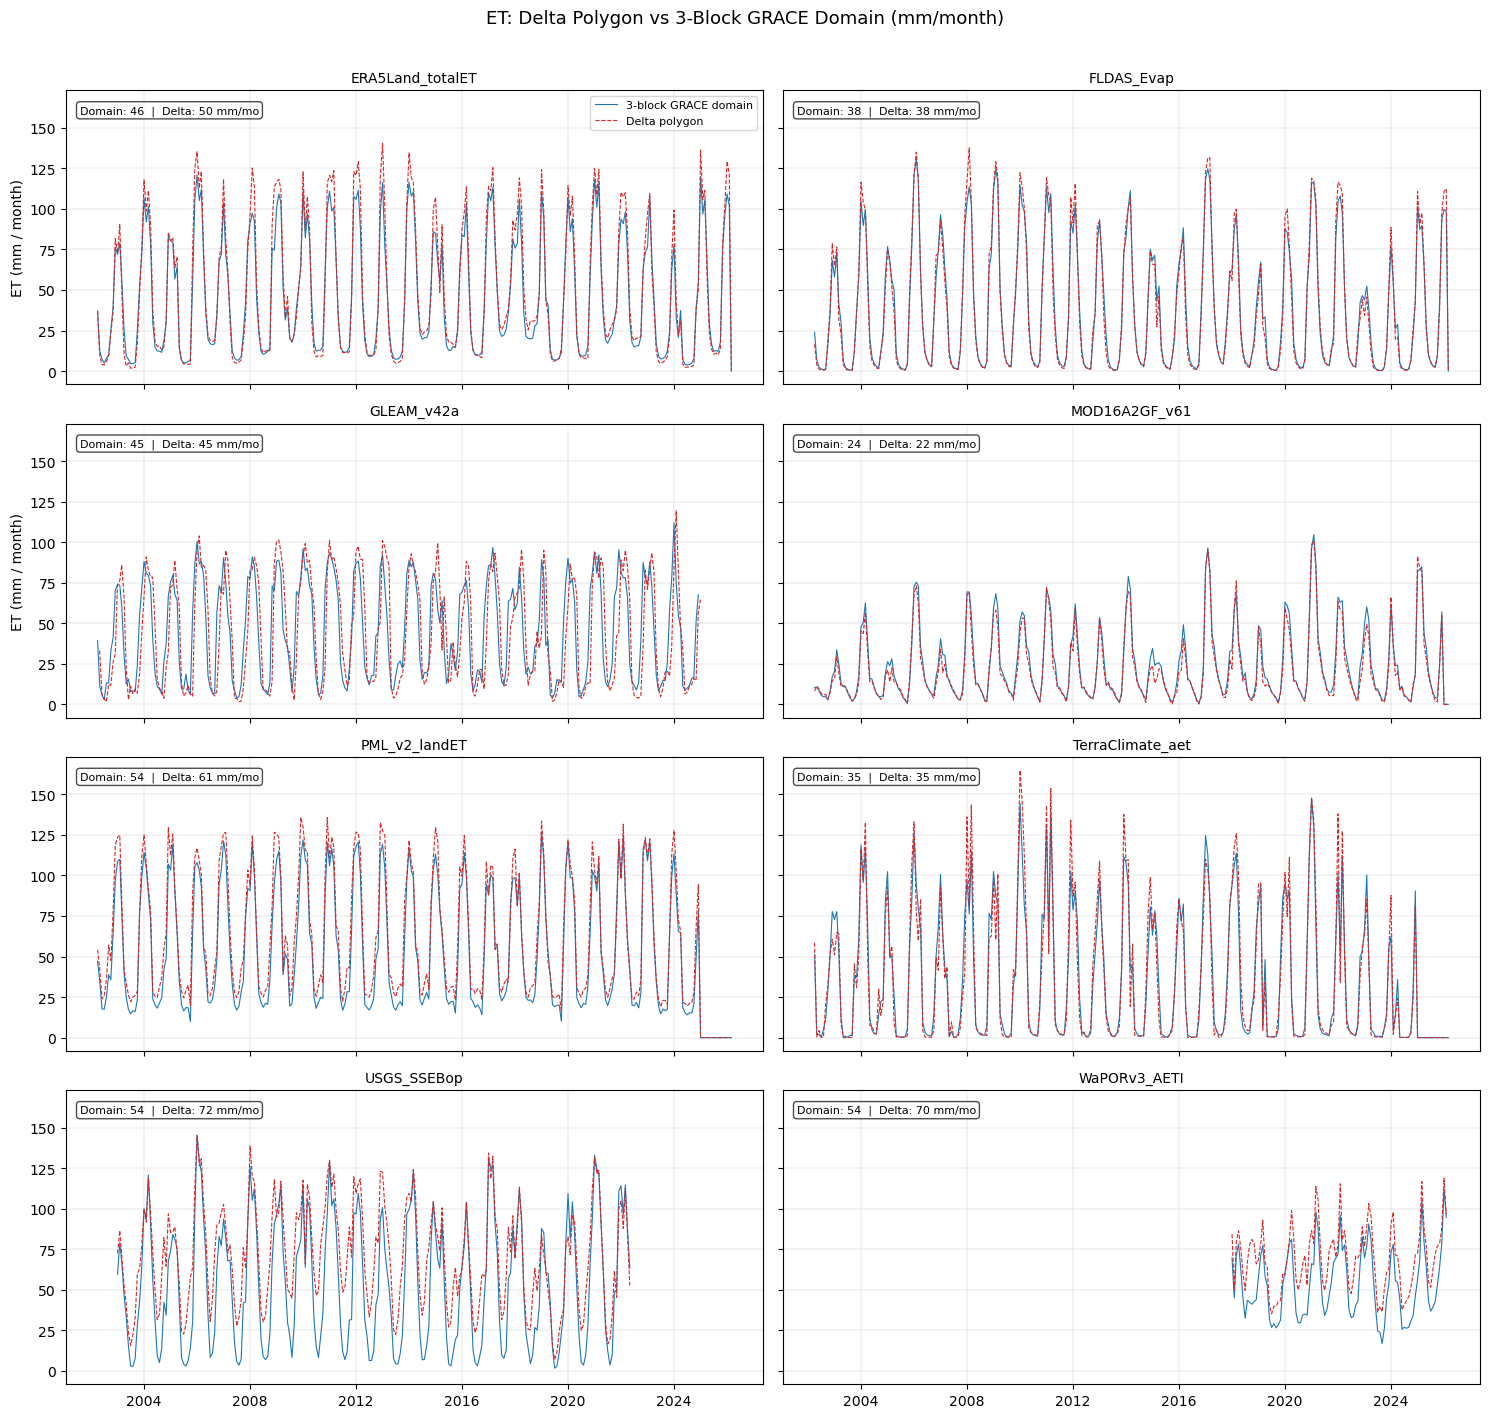


Saved: ../figures/ET comparison/grace_3block/et_delta_vs_grace_domain.png


In [27]:
# ── Compute ET over delta polygon for comparison ──

DELTA_ET_CSV = FIG_DIR / "et_monthly_delta_poly.csv"

# Build EE geometry from delta shapefile
delta_poly_ee = ee.Geometry.MultiPolygon(
    [list(map(list, p.exterior.coords))
     for p in (delta_union.geoms if delta_union.geom_type == "MultiPolygon"
               else [delta_union])],
    proj="EPSG:4326", geodesic=True)
delta_area_m2 = float(delta_poly_ee.area(maxError=1).getInfo())
print(f"Delta polygon area (EE): {delta_area_m2/1e6:.0f} km²")

# ── EE products over delta polygon ──
if RUN_EE:
    dfs_delta = []
    for ds in DATASETS:
        ds_start = max(pd.to_datetime(START),
                       pd.to_datetime(ds["start"])).strftime("%Y-%m-%d")
        if pd.to_datetime(ds_start) >= pd.to_datetime(END):
            continue
        ic = (ee.ImageCollection(ds["id"])
              .filterBounds(delta_poly_ee).filterDate(ds_start, END))
        mic = make_monthly_et_ic(ic, ds["to_mm"], ds_start, END)
        n = int(mic.size().getInfo())
        print(f"  {ds['name']}: {n} months")
        totals = monthly_totals_m3_chunked(mic, delta_poly_ee,
                                           scale_m=ds["scale"])
        dfs_delta.append(et_totals_to_df(totals, ds["name"], delta_area_m2))

    df_et_delta = pd.concat(dfs_delta, ignore_index=True).sort_values(
        ["dataset", "date"])
    df_et_delta.to_csv(DELTA_ET_CSV, index=False)
    print(f"Saved: {DELTA_ET_CSV}  ({len(df_et_delta)} rows)")
else:
    df_et_delta = pd.read_csv(DELTA_ET_CSV, parse_dates=["date"])
    print(f"Loaded cached: {DELTA_ET_CSV}  ({len(df_et_delta)} rows)")

# ── GLEAM over delta polygon ──
if GLEAM_FILES:
    blon0_d, blat0_d, blon1_d, blat1_d = delta_union.bounds
    dsets_d = []
    for f in GLEAM_FILES:
        ds = xr.open_dataset(f)
        dsets_d.append(ds.sel(lon=slice(blon0_d - 0.5, blon1_d + 0.5),
                              lat=slice(blat1_d + 0.5, blat0_d - 0.5)))
    da_gleam_d = xr.concat(dsets_d, dim="time").sortby("time")
    for ds in dsets_d:
        ds.close()

    et_da_d = da_gleam_d["E"]
    lats_d = et_da_d["lat"].values
    lons_d = et_da_d["lon"].values
    dlat_d = abs(float(np.median(np.diff(lats_d))))
    dlon_d = abs(float(np.median(np.diff(lons_d))))

    pa_d = (R**2 * np.deg2rad(dlon_d)
            * np.abs(np.sin(np.deg2rad(lats_d + dlat_d / 2))
                     - np.sin(np.deg2rad(lats_d - dlat_d / 2))))
    area_2d_d = np.broadcast_to(pa_d[:, None], (len(lats_d), len(lons_d)))

    lon_grid_d, lat_grid_d = np.meshgrid(lons_d, lats_d)
    mask_d = contains(delta_union, lon_grid_d, lat_grid_d)
    total_area_d = float(area_2d_d[mask_d].sum())

    rows_d = []
    for t in range(et_da_d.shape[0]):
        vals = et_da_d.values[t]
        m3 = float(np.nansum(np.where(mask_d, vals, 0.0) * area_2d_d / 1000.0))
        mm_mean = (m3 / total_area_d) * 1000.0 if total_area_d > 0 else 0.0
        ts_val = pd.Timestamp(et_da_d["time"].values[t])
        rows_d.append({"dataset": "GLEAM_v42a", "date": ts_val,
                        "et_km3_total": m3 / 1e9, "et_mm_mean": mm_mean})

    df_gleam_d = pd.DataFrame(rows_d)
    df_gleam_d = df_gleam_d[(df_gleam_d["date"] >= START)
                            & (df_gleam_d["date"] < END)]
    da_gleam_d.close()

    df_et_delta = pd.concat([df_et_delta, df_gleam_d], ignore_index=True)
    df_et_delta = df_et_delta.sort_values(["dataset", "date"]).reset_index(drop=True)
    df_et_delta.to_csv(DELTA_ET_CSV, index=False)
    print(f"GLEAM delta: {len(df_gleam_d)} months")

# ── Apply SSEBop cleanup to delta df too ──
ssebop_d = df_et_delta["dataset"].str.contains("SSEBop", case=False)
if ssebop_d.any():
    z = df_et_delta.loc[ssebop_d, "et_km3_total"].le(1e-6)
    if z.sum() > 0:
        lr = df_et_delta.loc[ssebop_d & (df_et_delta["et_km3_total"] > 1e-6), "date"].max()
        df_et_delta.loc[ssebop_d & df_et_delta["et_km3_total"].le(1e-6), "et_km3_total"] = np.nan
        df_et_delta.loc[ssebop_d & df_et_delta["et_mm_mean"].le(1e-6), "et_mm_mean"] = np.nan
        if pd.notna(lr):
            df_et_delta.loc[ssebop_d & (df_et_delta["date"] > lr),
                            ["et_km3_total", "et_mm_mean"]] = np.nan

# ── Plot: delta polygon vs 3-block domain per model ──
all_models = sorted(df_et_all["dataset"].unique())
n_models = len(all_models)
ncols = 2
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for i, model in enumerate(all_models):
    ax = axes[i]
    s3 = df_et_all[df_et_all["dataset"] == model]
    sd = df_et_delta[df_et_delta["dataset"] == model]

    ax.plot(s3["date"], s3["et_mm_mean"], lw=0.8, label="3-block GRACE domain",
            color="#1f77b4")
    ax.plot(sd["date"], sd["et_mm_mean"], lw=0.8, label="Delta polygon",
            color="#d62728", ls="--")

    # annotate means
    m3 = s3["et_mm_mean"].mean()
    md = sd["et_mm_mean"].mean()
    ax.text(0.02, 0.95, f"Domain: {m3:.0f}  |  Delta: {md:.0f} mm/mo",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ax.set_title(model, fontsize=10)
    ax.grid(True, lw=0.2)

# hide unused subplots
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("ET (mm / month)")
if nrows > 1:
    axes[ncols].set_ylabel("ET (mm / month)")

fig.suptitle("ET: Delta Polygon vs 3-Block GRACE Domain (mm/month)",
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "et_delta_vs_grace_domain.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"\nSaved: {FIG_DIR / 'et_delta_vs_grace_domain.png'}")

In [28]:
# ── Drop implausible ET models based on delta-vs-domain diagnostic ──
DROP_MODELS = ["MOD16A2GF_v61", "FLDAS_Evap", "TerraClimate_aet"]

before = df_et_all["dataset"].nunique()
df_et_all = df_et_all[~df_et_all["dataset"].isin(DROP_MODELS)].reset_index(drop=True)
after = df_et_all["dataset"].nunique()
print(f"Dropped {DROP_MODELS} → {before} → {after} ET models remaining:")
for m in sorted(df_et_all["dataset"].unique()):
    print(f"  {m}")

Dropped ['MOD16A2GF_v61', 'FLDAS_Evap', 'TerraClimate_aet'] → 8 → 5 ET models remaining:
  ERA5Land_totalET
  GLEAM_v42a
  PML_v2_landET
  USGS_SSEBop
  WaPORv3_AETI


## 5 — CHIRPS precipitation over 3-block union

In [29]:
CHIRPS_CSV = FIG_DIR / "chirps_monthly.csv"

def make_monthly_precip(daily_ic, band, start_date, end_date):
    start = ee.Date(start_date)
    def month_img(m):
        m = ee.Number(m)
        m0 = start.advance(m, "month")
        m1 = m0.advance(1, "month")
        sub = daily_ic.filterDate(m0, m1).select(band)
        mm = ee.Image(ee.Algorithms.If(sub.size().gt(0), sub.sum(),
                                        ee.Image.constant(0)))
        return (mm.rename("ppt_mm")
                .set({"system:time_start": m0.millis(),
                      "system:index": m0.format("YYYYMM")}))
    months = ee.List(ee.Algorithms.If(
        ee.Date(end_date).difference(start, "month").toInt().gt(0),
        monthly_sequence(start_date, end_date), ee.List([])))
    return ee.ImageCollection.fromImages(months.map(month_img))

def ppt_totals_m3_chunked(ic, region, scale_m=5500, chunk_n=120, tile_scale=8):
    n = int(ic.size().getInfo())
    if n == 0:
        return {}
    imgs = ic.toList(n)
    out = {}
    for i in range(0, n, chunk_n):
        sub = ee.ImageCollection.fromImages(imgs.slice(i, min(i + chunk_n, n)))
        def to_m3(img):
            img = ee.Image(img)
            idx = ee.String(img.get("system:index"))
            return (img.select("ppt_mm").unmask(0)
                    .divide(1000).multiply(ee.Image.pixelArea())
                    .rename("ppt_m3").set("system:index", idx))
        d = sub.map(to_m3).toBands().reduceRegion(
            reducer=ee.Reducer.sum(), geometry=region,
            scale=scale_m, maxPixels=1e13, tileScale=tile_scale).getInfo()
        out.update(d)
    return out

if RUN_EE:
    chirps_daily = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
                    .filterBounds(block_geom).filterDate(START, END))
    chirps_monthly_ic = make_monthly_precip(chirps_daily, "precipitation", START, END)
    n_p = int(chirps_monthly_ic.size().getInfo())
    print(f"CHIRPS monthly bins: {n_p}")

    ppt_totals = ppt_totals_m3_chunked(chirps_monthly_ic, block_geom)

    rows = []
    for k, v in ppt_totals.items():
        yyyymm = k.split("_")[0]
        date = pd.to_datetime(yyyymm + "01", format="%Y%m%d")
        m3 = float(v) if v is not None else 0.0
        rows.append({"dataset": "CHIRPS_monthly", "date": date,
                      "ppt_km3_total": m3 / 1e9,
                      "ppt_mm_mean": (m3 / block_area_m2) * 1000.0})
    df_chirps = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    df_chirps.to_csv(CHIRPS_CSV, index=False)
    print(f"Saved: {CHIRPS_CSV}  ({len(df_chirps)} rows)")
else:
    df_chirps = pd.read_csv(CHIRPS_CSV, parse_dates=["date"])
    print(f"Loaded cached: {CHIRPS_CSV}  ({len(df_chirps)} rows)")

CHIRPS monthly bins: 288
Saved: ../figures/ET comparison/grace_3block/chirps_monthly.csv  (288 rows)


## 6 — GRACE TWS over 3-block union

In [30]:
import re

GRACE_EE_ID = "NASA/GRACE/MASS_GRIDS_V04/MASCON_CRI"
BAND = "lwe_thickness"
GRACE_CSV = FIG_DIR / "grace_monthly.csv"

def grace_totals_m3_chunked(grace_ic, region, scale_m=55660,
                             chunk_n=60, tile_scale=8):
    n = int(grace_ic.size().getInfo())
    if n == 0:
        return {}
    imgs = grace_ic.toList(n)
    out = {}
    def prep(img):
        img = ee.Image(img)
        idx = ee.Date(img.get("system:time_start")).format("YYYYMM")
        return (img.select(BAND).unmask(0)
                .divide(100.0).multiply(ee.Image.pixelArea())
                .rename("tws_m3").set("system:index", idx))
    for i in range(0, n, chunk_n):
        sub = ee.ImageCollection.fromImages(
            imgs.slice(i, min(i + chunk_n, n))).map(prep)
        d = sub.toBands().reduceRegion(
            reducer=ee.Reducer.sum(), geometry=region,
            scale=scale_m, maxPixels=1e13, tileScale=tile_scale).getInfo()
        out.update(d)
    return out

if RUN_EE:
    grace_ic = (ee.ImageCollection(GRACE_EE_ID)
                .filterBounds(block_geom).filterDate(START, END).select(BAND))
    print("GRACE images:", grace_ic.size().getInfo())

    g_totals = grace_totals_m3_chunked(grace_ic, block_geom)

    rows = []
    for k, v in g_totals.items():
        m = re.search(r"(\d{6,8})", k)
        if m is None:
            continue
        code = m.group(1)
        date = pd.to_datetime(code + ("01" if len(code) == 6 else ""),
                               format="%Y%m%d")
        m3 = float(v) if v is not None else 0.0
        rows.append({"date": date,
                      "grace_km3_total": m3 / 1e9,
                      "grace_cm_mean": (m3 / block_area_m2) * 100.0})
    df_grace = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    df_grace.to_csv(GRACE_CSV, index=False)
    print(f"Saved: {GRACE_CSV}  ({len(df_grace)} rows)")
else:
    df_grace = pd.read_csv(GRACE_CSV, parse_dates=["date"])
    print(f"Loaded cached: {GRACE_CSV}  ({len(df_grace)} rows)")

GRACE images: 238
Saved: ../figures/ET comparison/grace_3block/grace_monthly.csv  (238 rows)


## 7 — Mohembo inflow

Mohembo rows: 591
Range: 1974-12-01 → 2024-02-01


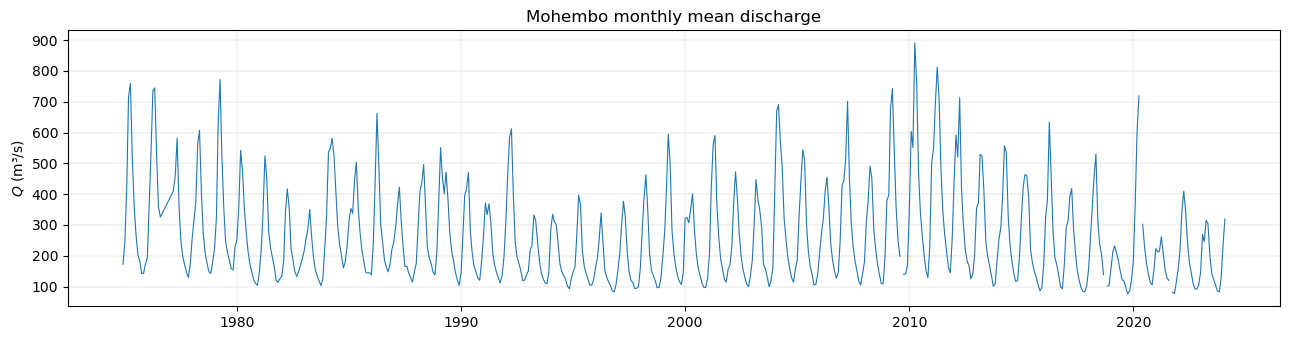

In [31]:
monthly = pd.read_csv(MOHEMBO_MONTHLY, parse_dates=["month"])

# Convert Q (m³/s) → volume per month
monthly["days_in_month"] = monthly["month"].dt.days_in_month
monthly["Qin_m3s"] = monthly["Q_m3s_monthly_mean"]
monthly["Qin_km3"] = monthly["Qin_m3s"] * monthly["days_in_month"] * 86400 / 1e9
monthly["Qin_mm"]  = monthly["Qin_km3"] * 1e9 / block_area_m2 * 1000.0
monthly = monthly.rename(columns={"month": "date"})
q_mohembo = monthly[["date", "Qin_m3s", "Qin_km3", "Qin_mm"]].copy()

print(f"Mohembo rows: {len(q_mohembo)}")
print(f"Range: {q_mohembo['date'].min().date()} → {q_mohembo['date'].max().date()}")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(q_mohembo["date"], q_mohembo["Qin_m3s"], lw=0.8)
ax.set_title("Mohembo monthly mean discharge")
ax.set_ylabel(r"$Q$ (m³/s)")
ax.grid(True, lw=0.2)
plt.tight_layout()
plt.show()

## 8 — Mass-balance assembly

In [32]:
def to_month_start(s):
    return pd.to_datetime(s).dt.to_period("M").dt.to_timestamp("s")

# Normalize all dates to month-start
df_et_all = df_et_all.copy()
df_et_all["date"] = to_month_start(df_et_all["date"])
df_chirps["date"] = to_month_start(df_chirps["date"])
df_grace["date"]  = to_month_start(df_grace["date"])
q_mohembo["date"] = to_month_start(q_mohembo["date"])

# Collapse any duplicate months
df_et_all  = df_et_all.groupby(["date", "dataset"], as_index=False).mean(numeric_only=True)
df_chirps  = df_chirps.groupby(["date", "dataset"], as_index=False).mean(numeric_only=True)
df_grace   = df_grace.groupby("date", as_index=False).mean(numeric_only=True)
q_mohembo  = q_mohembo.groupby("date", as_index=False).mean(numeric_only=True)

# 1) ET ensemble median
et_km3_wide = (df_et_all.pivot_table(index="date", columns="dataset",
                                      values="et_km3_total", aggfunc="median")
               .sort_index())
et_mm_wide = (df_et_all.pivot_table(index="date", columns="dataset",
                                     values="et_mm_mean", aggfunc="median")
              .sort_index())
ETmm_med  = et_mm_wide.median(axis=1, skipna=True).rename("ETmm")
ETkm3_med = et_km3_wide.median(axis=1, skipna=True).rename("ETkm3")

# 2) CHIRPS
p_ser = df_chirps.set_index("date")
Pmm   = p_ser["ppt_mm_mean"].rename("Pmm")
Pkm3  = p_ser["ppt_km3_total"].rename("Pkm3")

# 3) GRACE storage anomaly + monthly ΔS
gr = (df_grace.set_index("date")
      [["grace_cm_mean", "grace_km3_total"]]
      .sort_index()
      .rename(columns={"grace_cm_mean": "GRACEcm", "grace_km3_total": "GRACEkm3"}))
dS_km3 = gr["GRACEkm3"].diff().rename("dS_km3")
dS_cm  = gr["GRACEcm"].diff().rename("dS_cm")

gap_days = gr.index.to_series().diff().dt.days
n_gaps = int((gap_days > 45).sum())
if n_gaps > 0:
    print(f"GRACE gaps > 45 days: {n_gaps} — setting ΔS to NaN across those.")
    dS_km3[gap_days > 45] = np.nan
    dS_cm[gap_days > 45]  = np.nan

# 4) Qin
qin = q_mohembo.set_index("date")[["Qin_m3s", "Qin_km3", "Qin_mm"]].sort_index()

# 5) Combine
df_balance = pd.concat([Pmm, Pkm3, ETmm_med, ETkm3_med,
                         gr, dS_km3, dS_cm, qin], axis=1).sort_index()

# Residual: Qout + G ≈ Qin + P − ET − ΔS
df_balance["Qout_G_km3"] = (df_balance["Qin_km3"] + df_balance["Pkm3"]
                             - df_balance["ETkm3"] - df_balance["dS_km3"])
df_balance["has_closure"] = (df_balance[["Qin_km3", "Pkm3", "ETkm3", "dS_km3"]]
                             .notna().all(axis=1))

df_balance = df_balance.loc[df_balance.index >= "2002-04-01"].copy()
print(f"Balance table: {len(df_balance)} months, "
      f"{df_balance['has_closure'].sum()} with full closure data")
df_balance.head(10)

GRACE gaps > 45 days: 21 — setting ΔS to NaN across those.
Balance table: 288 months, 195 with full closure data


,Pmm,Pkm3,ETmm,ETkm3,GRACEcm,GRACEkm3,dS_km3,dS_cm,Qin_m3s,Qin_km3,Qin_mm,Qout_G_km3,has_closure
date,,,,,,,,,,,,,
2002-04-01,22.770576,7.543119,39.253117,13.000976,-2.659414,-8.809735,NaN,NaN,472.675333,1.225174,3.698461,NaN,False
2002-05-01,0.226415,0.075004,12.260443,4.061469,-1.288712,-4.269065,4.540670,1.370702,388.285484,1.039984,3.139422,-7.487151,True
2002-06-01,0.010150,0.003362,7.243765,2.399613,NaN,NaN,NaN,NaN,270.247667,0.700482,2.114560,NaN,False
2002-07-01,0.015582,0.005162,5.108552,1.692290,-5.564862,-18.434498,NaN,NaN,199.344516,0.533924,1.611769,NaN,False
2002-08-01,0.289313,0.095839,13.105587,4.340685,-6.840002,-22.658604,-4.224107,-1.275140,155.478065,0.416432,1.257094,0.395693,True
2002-09-01,2.345674,0.777042,13.141121,4.352454,-5.930015,-19.644127,3.014477,0.909987,128.508000,0.333093,1.005514,-6.256796,True
2002-10-01,23.369019,7.741363,33.263687,11.017225,-4.614847,-15.287423,4.356705,1.315168,107.130968,0.286940,0.866191,-7.345627,True
2002-11-01,46.588140,15.433069,40.985144,13.574639,-6.564019,-21.744368,-6.456945,-1.949172,100.049667,0.259329,0.782841,8.574705,True
2002-12-01,77.574902,25.697932,76.311027,25.279253,-6.407135,-21.224664,0.519704,0.156884,136.228065,0.364873,1.101451,0.263848,True


## 9 — Mass-balance plots

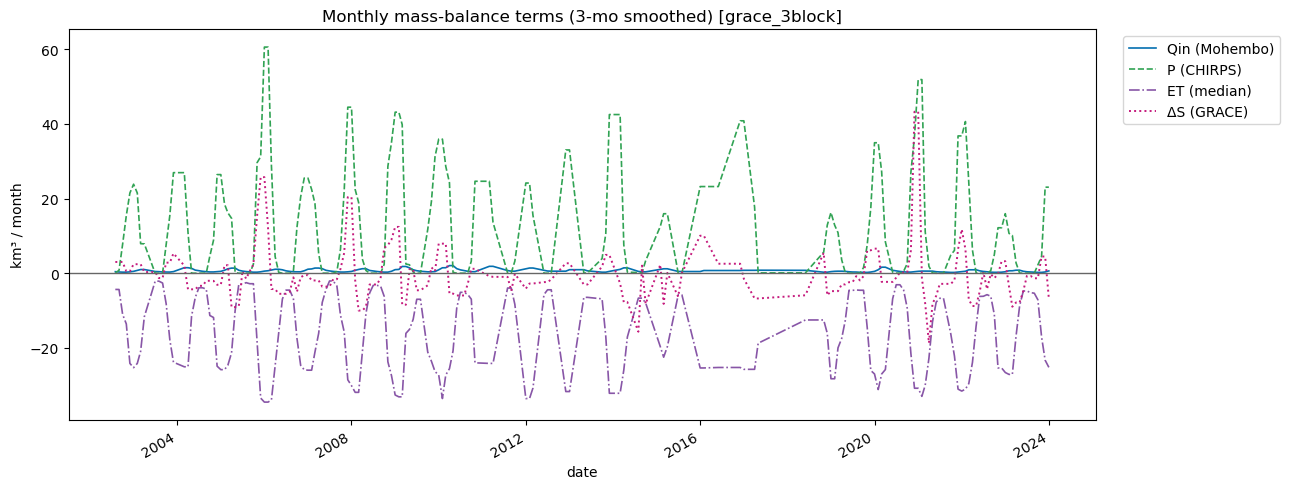

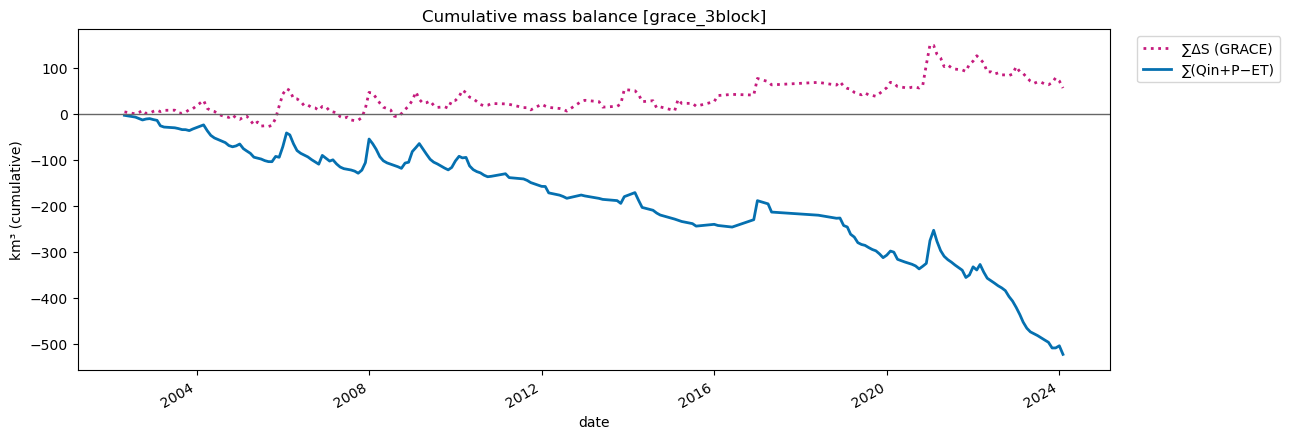

In [36]:
TERM_STYLE = {
    "Qin (Mohembo)": {"color": "#0570b0", "ls": "-",  "lw": 1.2},
    "P (CHIRPS)":    {"color": "#31a354", "ls": "--", "lw": 1.2},
    "ET (median)":   {"color": "#8856a7", "ls": "-.", "lw": 1.2},
    "ΔS (GRACE)":    {"color": "#c51b7d", "ls": ":",  "lw": 1.4},
}

dfc = df_balance[df_balance["has_closure"]].copy()

# ── Plot 1: monthly terms (3-mo smoothed) ──
plot_terms = pd.DataFrame(index=dfc.index)
plot_terms["Qin (Mohembo)"] = dfc["Qin_km3"]
plot_terms["P (CHIRPS)"]    = dfc["Pkm3"]
plot_terms["ET (median)"]   = -dfc["ETkm3"]
plot_terms["ΔS (GRACE)"]    = dfc["dS_km3"]

fig, ax = plt.subplots(figsize=(13, 5))
for col in plot_terms.columns:
    sty = TERM_STYLE[col]
    plot_terms[col].rolling(3, center=True).median().plot(
        ax=ax, color=sty["color"], ls=sty["ls"], lw=sty["lw"], label=col)
ax.axhline(0, lw=1, c="0.4")
ax.set_title(f"Monthly mass-balance terms (3-mo smoothed) [{GEOM_TAG}]")
ax.set_ylabel("km³ / month")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIG_DIR / "mass_balance_terms.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: cumulative ──
cum = pd.DataFrame(index=dfc.index)
cum["∑ΔS (GRACE)"]   = dfc["dS_km3"].cumsum()
cum["∑(Qin+P−ET)"]   = (dfc["Qin_km3"] + dfc["Pkm3"] - dfc["ETkm3"]).cumsum()

fig, ax = plt.subplots(figsize=(13, 4.5))
cum["∑ΔS (GRACE)"].plot(ax=ax, color="#c51b7d", ls=":", lw=2, label="∑ΔS (GRACE)")
cum["∑(Qin+P−ET)"].plot(ax=ax, color="#0570b0", ls="-", lw=2, label="∑(Qin+P−ET)")
ax.axhline(0, lw=1, c="0.4")
ax.set_title(f"Cumulative mass balance [{GEOM_TAG}]")
ax.set_ylabel("km³ (cumulative)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIG_DIR / "cumulative_sums.png", dpi=150, bbox_inches="tight")
plt.show()

## 10 — Per-ET-model cumulative plots

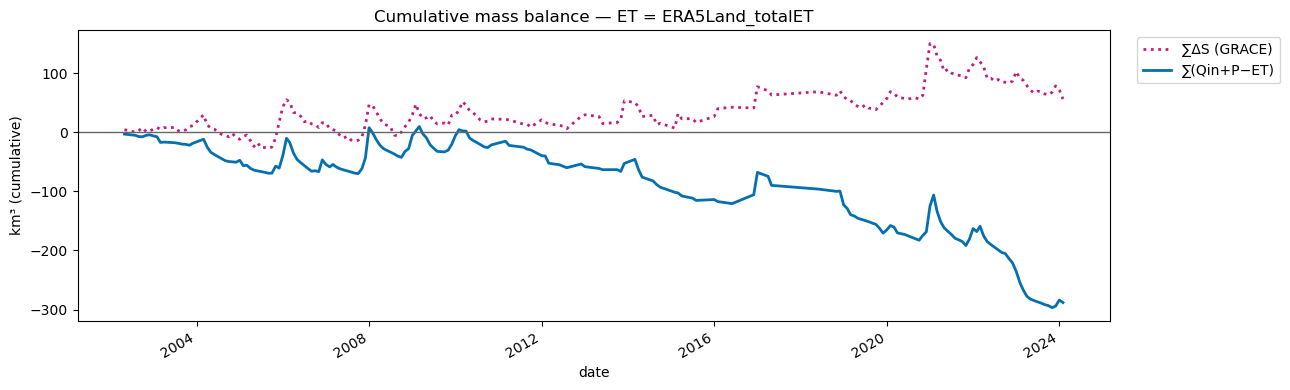

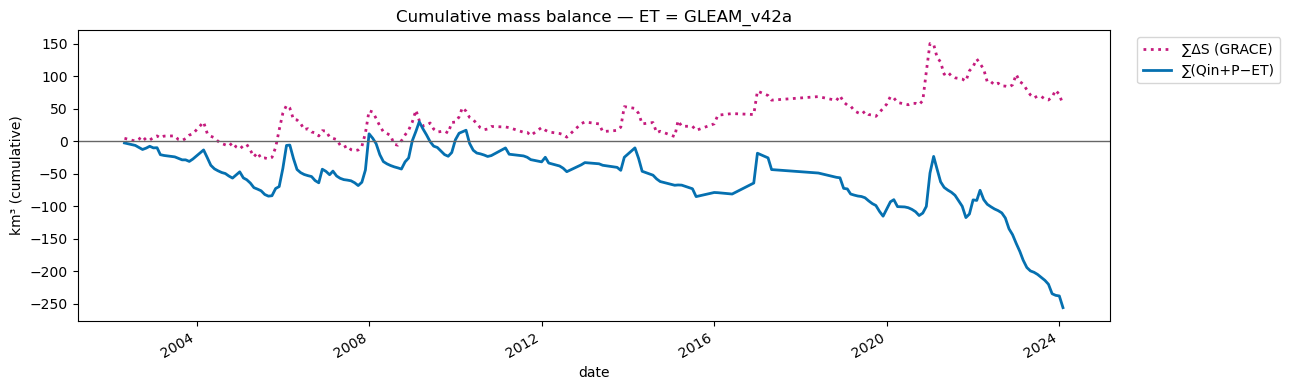

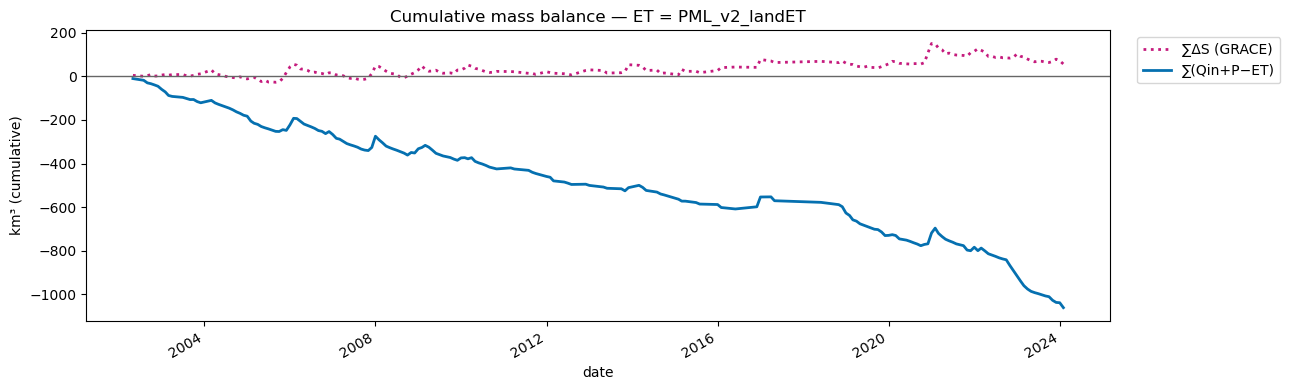

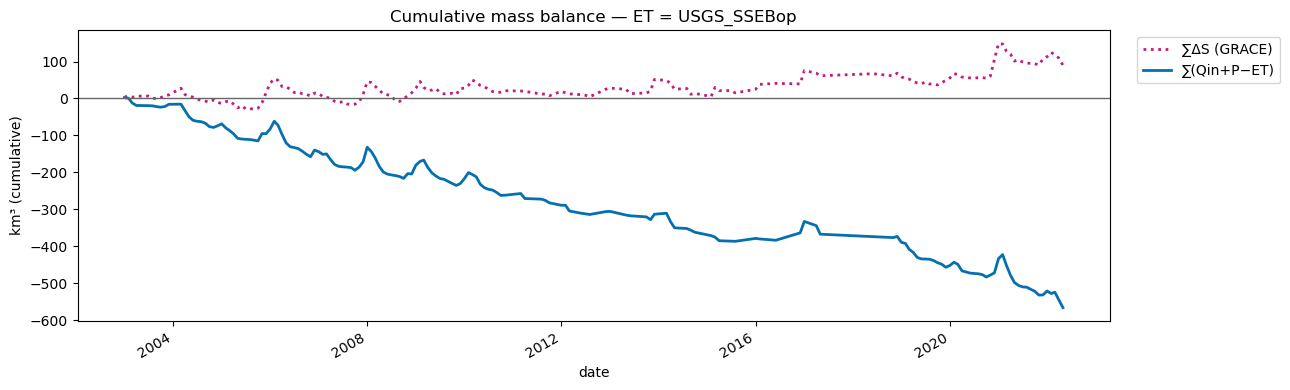

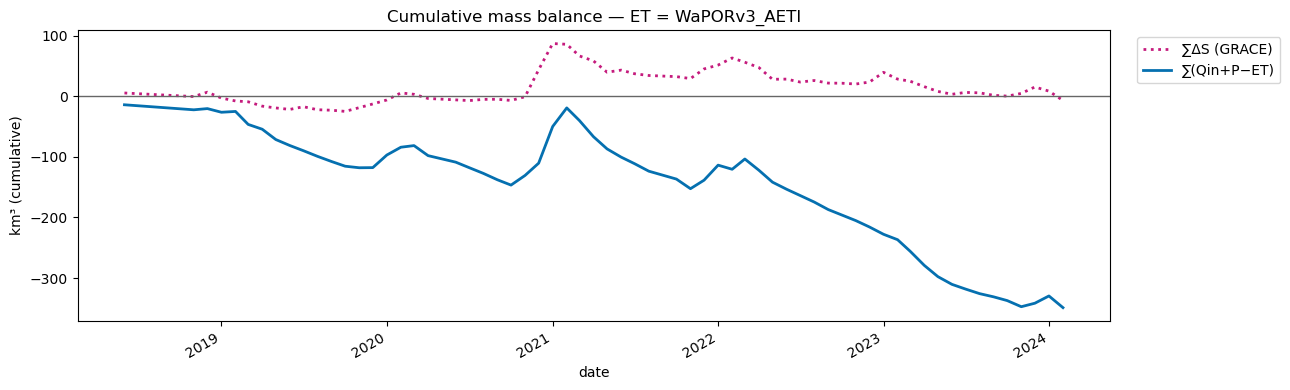

In [34]:
base_mask = df_balance[["Qin_km3", "Pkm3", "dS_km3"]].notna().all(axis=1)
dfc_base = df_balance.loc[base_mask].copy()

et_km3_aligned = et_km3_wide.reindex(dfc_base.index)

for et_name in et_km3_aligned.columns:
    dfc = dfc_base.copy()
    dfc["ETkm3_model"] = et_km3_aligned[et_name]
    dfc = dfc[dfc["ETkm3_model"].notna()]
    if len(dfc) < 6:
        continue

    cum = pd.DataFrame(index=dfc.index)
    cum["∑ΔS (GRACE)"] = dfc["dS_km3"].cumsum()
    cum[f"∑(Qin+P−ET)"] = (dfc["Qin_km3"] + dfc["Pkm3"] - dfc["ETkm3_model"]).cumsum()

    fig, ax = plt.subplots(figsize=(13, 4))
    cum["∑ΔS (GRACE)"].plot(ax=ax, color="#c51b7d", ls=":", lw=2, label="∑ΔS (GRACE)")
    cum["∑(Qin+P−ET)"].plot(ax=ax, color="#0570b0", ls="-", lw=2, label="∑(Qin+P−ET)")
    ax.axhline(0, lw=1, c="0.4")
    ax.set_title(f"Cumulative mass balance — ET = {et_name}")
    ax.set_ylabel("km³ (cumulative)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    slug = et_name.replace("/", "_").replace(" ", "_")
    model_dir = FIG_DIR / "single-model" / slug
    model_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(model_dir / "cumulative_sums.png", dpi=150, bbox_inches="tight")
    plt.show()

## 11 — Save outputs

In [35]:
df_et_all.to_csv(FIG_DIR / "et_monthly.csv", index=False)
df_chirps.to_csv(FIG_DIR / "chirps_monthly.csv", index=False)
df_grace.to_csv(FIG_DIR / "grace_monthly.csv", index=False)
q_mohembo.to_csv(FIG_DIR / "mohembo_monthly.csv", index=False)

bal_out = (df_balance.reset_index().rename(columns={"index": "date"})
           if "date" not in df_balance.columns else df_balance)
bal_out.to_csv(FIG_DIR / "mass_balance.csv", index=False)

with open(FIG_DIR / "geometry_info.txt", "w") as fh:
    fh.write(f"GEOM = {GEOM_TAG}\n")
    fh.write(f"block_area_km2 = {block_area_m2 / 1e6:.1f}\n")
    fh.write(f"n_blocks = {len(USE_BLOCKS)}\n")
    for b in USE_BLOCKS:
        fh.write(f"  {b['block_id']} ({b['quadrant']}): "
                 f"lon {b['lon0']:.2f}–{b['lon1']:.2f}, "
                 f"lat {b['lat0']:.2f}–{b['lat1']:.2f}\n")

print(f"All outputs saved to {FIG_DIR.resolve()}")

All outputs saved to /Users/octaviacrompton/Projects/dswe-inman-lyons/figures/ET comparison/grace_3block
